In [12]:
import numpy as np
import pandas as pd

# import load_data
# import cutpoint_analysis

import os
import pickle
# import datetime
import time

from skimpy import skim

import matplotlib.pyplot as plt
import seaborn as sns

from statistics import median

from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate
from sklearn.metrics import confusion_matrix, precision_score, recall_score, roc_auc_score, average_precision_score, RocCurveDisplay, accuracy_score

import mlflow
from mlflow.models import infer_signature

# Load analysis datasets and model input feature name list

Two dataframes - one for each imputation method:

- `imp_v1_df`: Missing values imputed with median value for feature in analysis set.
- `imp_v2_df`: Missing lab result values imputed with patient's most recent lab result value if available. If there is not lab result available, the median of the feature in the analysis dataset was used.

In [3]:
imp_v1_df = pd.read_csv(os.getenv('AKI_CSV_DIR') + '/analysis_dataset_median_imputed_normalized_includes_bSCr.csv')
imp_v2_df = pd.read_csv(os.getenv('AKI_CSV_DIR') + '/analysis_dataset_latest_lab_and_median_imputed_normalized_includes_bSCr.csv')

In [7]:
non_feature_cols = [
    'pn.site',
    'vps.site',
    'person_id',
    'Medical.LOS',
    'Physical.LOS',
    'hashid',
    'Female',
    'aki_12hrs',
    'aki_12hrs_any',
    'aki_72hrs',
    'aki_72hrs_any',
    'CaseIndex',
    'adt_datetime',
    'medical_dc_dt',
    'Outcome',
    'baseline_used'
]

full_modeling_feature_list = [feature for feature in imp_v1_df.columns if feature not in non_feature_cols]

# Single-Input Model Training

Train models on individual features and find AUC as a measure of performance.

## Logistic Regresion

Make sure target features are encoded as integers.

In [9]:
imp_v1_df['aki_72hrs_any'] = [int(np.round(aki)) for aki in imp_v1_df['aki_72hrs_any']]
imp_v2_df['aki_72hrs_any'] = [int(np.round(aki)) for aki in imp_v2_df['aki_72hrs_any']]

In [10]:
def get_metrics_for_single_feature_logreg_model(df, 
                                                input_feature_name, 
                                                target_feature_name='aki_72hrs_any',
                                                max_iter=5000,
                                                random_state=343):
    X = df[input_feature_name].to_numpy()
    y = df[target_feature_name].to_numpy()

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

    model = LogisticRegression(class_weight='balanced', max_iter=max_iter, random_state=random_state)
    model.fit(X_train.reshape(-1, 1), y_train)

    y_score = model.predict_proba(X_test.reshape(-1, 1))
    auroc = roc_auc_score(y_test, y_score[:,1])
    auprc = average_precision_score(y_test, y_score[:,1])
    # tnr_90cp = cutpoint_analysis.get_tnr_at_cutpoint(y_test, y_score[:,1], cutpoint=0.9, max_iteration_count = 10000)
    # tnr_50cp = cutpoint_analysis.get_tnr_at_cutpoint(y_test, y_score[:,1], cutpoint=0.5, max_iteration_count = 10000)
    # tpr_90cp = cutpoint_analysis.get_tnr_at_cutpoint(y_test, y_score[:,1], cutpoint=0.9, max_iteration_count = 10000)
    # tpr_50cp = cutpoint_analysis.get_tnr_at_cutpoint(y_test, y_score[:,1], cutpoint=0.5, max_iteration_count = 10000)

    results_dict = {
        'input_feature': input_feature_name,
        'auroc': auroc,
        'auprc': auprc#,
        # 'tnr_90cp': tnr_90cp,
        # 'tnr_50cp': tnr_50cp,
        # 'tpr_90cp': tpr_90cp,
        # 'tpr_50cp': tpr_50cp
    }

    return results_dict

In [13]:
logreg_results_dict_list_v1 = []
logreg_results_dict_list_v2 = []

for feature in full_modeling_feature_list:
    results_dict_v1 = get_metrics_for_single_feature_logreg_model(
        imp_v1_df, 
        feature, 
        target_feature_name='aki_72hrs_any',
        max_iter=5000,
        random_state=343
    )
    logreg_results_dict_list_v1.append(results_dict_v1)
    
    results_dict_v2 = get_metrics_for_single_feature_logreg_model(
        imp_v1_df, 
        feature, 
        target_feature_name='aki_72hrs_any',
        max_iter=5000,
        random_state=343
    )
    logreg_results_dict_list_v2.append(results_dict_v2)

logreg_results_df_v1 = pd.DataFrame(logreg_results_dict_list_v1)
logreg_results_df_v2 = pd.DataFrame(logreg_results_dict_list_v2)

logreg_results_df_v1['auroc_v1'] = logreg_results_df_v1['auroc'].copy()
logreg_results_df_v1['auprc_v1'] = logreg_results_df_v1['auprc'].copy()
logreg_results_df_v1.drop(['auroc', 'auprc'], axis=1, inplace=True)

logreg_results_df_v2['auroc_v2'] = logreg_results_df_v2['auroc'].copy()
logreg_results_df_v2['auprc_v2'] = logreg_results_df_v2['auprc'].copy()
logreg_results_df_v2.drop(['auroc', 'auprc'], axis=1, inplace=True)

logreg_results_df = logreg_results_df_v1.merge(
    logreg_results_df_v2,
    on='input_feature',
    how='inner'
)

In [14]:
logreg_results_df

,input_feature,auroc_v1,auprc_v1,auroc_v2,auprc_v2
0,age,0.593807,0.032831,0.593807,0.032831
1,bSCr_prior,0.565184,0.128242,0.565184,0.128242
2,baseline_bSCr,0.563993,0.061850,0.563993,0.061850
3,anc_min,0.524428,0.024148,0.524428,0.024148
4,be_min,0.539890,0.030398,0.539890,0.030398
...,...,...,...,...,...
180,nephrotoxic_med_type_count_eq_0,0.611244,0.029147,0.611244,0.029147
181,nephrotoxic_med_type_count_eq_1,0.538289,0.024270,0.538289,0.024270
182,nephrotoxic_med_type_count_eq_2,0.535741,0.024503,0.535741,0.024503
183,nephrotoxic_med_type_count_gt_eq_3,0.537214,0.024866,0.537214,0.024866


In [ ]:
logreg_results_df = pd.read_csv(os.getenv('AKI_CSV_DIR') + '/2024-01-29 - Single Feature Logistic Regression Performance Metrics (Imputation v1, AUPRC).csv')

baseline_bSCr_results_dict = get_metrics_for_single_feature_logreg_model(df, 
                                                                        'baseline_bSCr', 
                                                                        target_feature_name='aki_72hrs_any',
                                                                        max_iter=5000,
                                                                        random_state=343)

logreg_results_df = pd.concat([logreg_results_df, pd.DataFrame([baseline_bSCr_results_dict])])

Max number of iterations reached - returning results early.
Max number of iterations reached - returning results early.
Max number of iterations reached - returning results early.
Max number of iterations reached - returning results early.


In [ ]:
run_logreg_single_feature_auc = False

if run_logreg_single_feature_auc:
    logreg_results_dict_list = []
    
    for feature in full_modeling_feature_list:
        results_dict = get_metrics_for_single_feature_logreg_model(df, 
                                                                feature, 
                                                                target_feature_name='aki_72hrs_any',
                                                                max_iter=5000,
                                                                random_state=343)
        logreg_results_dict_list.append(results_dict)
    
    logreg_results_df = pd.DataFrame(logreg_results_dict_list)
    logreg_results_df.to_csv(os.getenv('AKI_CSV_DIR') + '/2024-01-29 - Single Feature Logistic Regression Performance Metrics (Imputation v1, AUPRC).csv', index=False)
else:
    logreg_results_df = pd.read_csv(os.getenv('AKI_CSV_DIR') + '/2024-01-29 - Single Feature Logistic Regression Performance Metrics (Imputation v1, AUPRC).csv')

## SVC

In [16]:
def get_metrics_for_single_feature_svc_model(df, 
                                            input_feature_name, 
                                            target_feature_name='aki_72hrs_any',
                                            max_iter=-1,
                                            random_state=343):
    X = df[input_feature_name].to_numpy()
    y = df[target_feature_name].to_numpy()

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

    model = SVC(class_weight='balanced', max_iter=max_iter, random_state=random_state, probability=True)
    model.fit(X_train.reshape(-1, 1), y_train)

    y_score = model.predict_proba(X_test.reshape(-1, 1))
    auroc = roc_auc_score(y_test, y_score[:,1])
    auprc = average_precision_score(y_test, y_score[:,1])

    results_dict = {
        'input_feature': input_feature_name,
        'model_type': 'SVC',
        'auroc': auroc,
        'auprc': auprc
    }

    return results_dict

In [17]:
svc_results_dict_list_v1 = []
svc_results_dict_list_v2 = []

for feature in full_modeling_feature_list:
    results_dict_v1 = get_metrics_for_single_feature_svc_model(
        imp_v1_df, 
        feature, 
        target_feature_name='aki_72hrs_any',
        max_iter=5000,
        random_state=343
    )
    svc_results_dict_list_v1.append(results_dict_v1)
    
    results_dict_v2 = get_metrics_for_single_feature_svc_model(
        imp_v1_df, 
        feature, 
        target_feature_name='aki_72hrs_any',
        max_iter=5000,
        random_state=343
    )
    svc_results_dict_list_v2.append(results_dict_v2)

svc_results_df_v1 = pd.DataFrame(svc_results_dict_list_v1)
svc_results_df_v2 = pd.DataFrame(svc_results_dict_list_v2)

svc_results_df_v1['auroc_v1'] = svc_results_df_v1['auroc'].copy()
svc_results_df_v1['auprc_v1'] = svc_results_df_v1['auprc'].copy()
svc_results_df_v1.drop(['auroc', 'auprc'], axis=1, inplace=True)

svc_results_df_v2['auroc_v2'] = svc_results_df_v2['auroc'].copy()
svc_results_df_v2['auprc_v2'] = svc_results_df_v2['auprc'].copy()
svc_results_df_v2.drop(['auroc', 'auprc'], axis=1, inplace=True)

svc_results_df = svc_results_df_v1.merge(
    svc_results_df_v2,
    on='input_feature',
    how='inner'
)

C:\usr\sdrury\Anaconda3\Lib\site-packages\sklearn\svm\_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
C:\usr\sdrury\Anaconda3\Lib\site-packages\sklearn\svm\_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
C:\usr\sdrury\Anaconda3\Lib\site-packages\sklearn\svm\_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
C:\usr\sdrury\Anaconda3\Lib\site-packages\sklearn\svm\_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
C:\usr\sdrury\Anaconda3\Lib\site-packages\sklearn\svm\_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).

In [19]:
svc_results_df

,input_feature,model_type_x,auroc_v1,auprc_v1,model_type_y,auroc_v2,auprc_v2,svc_auroc_v1,svc_auprc_v1,svc_auroc_v2,svc_auprc_v2
0,age,SVC,0.477406,0.022697,SVC,0.477406,0.022697,0.477406,0.022697,0.477406,0.022697
1,bSCr_prior,SVC,0.382827,0.017478,SVC,0.382827,0.017478,0.382827,0.017478,0.382827,0.017478
2,baseline_bSCr,SVC,0.503878,0.026608,SVC,0.503878,0.026608,0.503878,0.026608,0.503878,0.026608
3,anc_min,SVC,0.500840,0.023749,SVC,0.500840,0.023749,0.500840,0.023749,0.500840,0.023749
4,be_min,SVC,0.596655,0.031048,SVC,0.596655,0.031048,0.596655,0.031048,0.596655,0.031048
...,...,...,...,...,...,...,...,...,...,...,...
180,nephrotoxic_med_type_count_eq_0,SVC,0.611244,0.029147,SVC,0.611244,0.029147,0.611244,0.029147,0.611244,0.029147
181,nephrotoxic_med_type_count_eq_1,SVC,0.461711,0.020608,SVC,0.461711,0.020608,0.461711,0.020608,0.461711,0.020608
182,nephrotoxic_med_type_count_eq_2,SVC,0.535741,0.024503,SVC,0.535741,0.024503,0.535741,0.024503,0.535741,0.024503
183,nephrotoxic_med_type_count_gt_eq_3,SVC,0.462786,0.020621,SVC,0.462786,0.020621,0.462786,0.020621,0.462786,0.020621


In [ ]:
svc_results_df = pd.read_csv(os.getenv('AKI_CSV_DIR') + '/2024-01-29 - Single Feature SVC Performance Metrics (Imputation v1, AUPRC).csv')

baseline_bSCr_results_dict_svc = get_metrics_for_single_feature_svc_model(df, 
                                                                        'baseline_bSCr', 
                                                                        target_feature_name='aki_72hrs_any',
                                                                        max_iter=2500,
                                                                        random_state=343)

svc_results_df = pd.concat([svc_results_df, pd.DataFrame([baseline_bSCr_results_dict_svc])])

C:\usr\sdrury\Anaconda3\Lib\site-packages\sklearn\svm\_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=2500).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


In [ ]:
run_svc_single_feature_auc = False
start_time = time.time()

if run_svc_single_feature_auc:
    svc_results_dict_list = []
    
    for feature in full_modeling_feature_list:
        elapsed_time = time.time() - start_time
        print('Elapsed time (minutes): %.2f' % (elapsed_time / 60))
        print('Starting modeling on ' + feature)
        results_dict = get_metrics_for_single_feature_svc_model(df, 
                                                                feature, 
                                                                target_feature_name='aki_72hrs_any',
                                                                max_iter=2500,
                                                                random_state=343)
        svc_results_dict_list.append(results_dict)
        print('Finished feature %d of %d' % (len(svc_results_dict_list), len(full_modeling_feature_list)))

    svc_results_df = pd.DataFrame(svc_results_dict_list)
    svc_results_df.to_csv(os.getenv('AKI_CSV_DIR') + '/2024-01-29 - Single Feature SVC Performance Metrics (Imputation v1, AUPRC).csv', index=False)
else:
    svc_results_df = pd.read_csv(os.getenv('AKI_CSV_DIR') + '/2024-01-29 - Single Feature SVC Performance Metrics (Imputation v1, AUPRC).csv')

In [23]:
logreg_results_df['logreg_auroc_v1'] = logreg_results_df['auroc_v1']
logreg_results_df['logreg_auprc_v1'] = logreg_results_df['auprc_v1']
logreg_results_df['logreg_auroc_v2'] = logreg_results_df['auroc_v2']
logreg_results_df['logreg_auprc_v2'] = logreg_results_df['auprc_v2']

svc_results_df['svc_auroc_v1'] = svc_results_df['auroc_v1']
svc_results_df['svc_auprc_v1'] = svc_results_df['auprc_v1']
svc_results_df['svc_auroc_v2'] = svc_results_df['auroc_v2']
svc_results_df['svc_auprc_v2'] = svc_results_df['auprc_v2']

# logreg_results_df['logreg_auprc'] = logreg_results_df['auprc']

combined_results_df = svc_results_df.drop(['auroc_v1', 'auprc_v1', 'auroc_v2', 'auprc_v2'], axis=1).merge(
    logreg_results_df.drop(['auroc_v1', 'auprc_v1', 'auroc_v2', 'auprc_v2'], axis=1),
    on='input_feature',
    how='inner'
)



# combined_results_df = svc_results_df[['input_feature', 'svc_auprc']].merge(logreg_results_df[['input_feature', 'logreg_auprc']], on='input_feature')
# combined_results_df['logreg_auc_minus_svc_auc'] = combined_results_df['logreg_auprc'] - combined_results_df['svc_auprc']

In [25]:
combined_results_df.to_csv(os.getenv('AKI_CSV_DIR') + '/2024-03-12 - logreg_and_svc_single_feature_auprc_and_auroc_both_imp_methods.csv', index=False)

# Colinearity Analysis

## Find correlation between all feature pairs

In [26]:
feature_corr_pearson_v1 = imp_v1_df[full_modeling_feature_list].corr(method='pearson')
feature_corr_kendall_v1 = imp_v1_df[full_modeling_feature_list].corr(method='kendall')
feature_corr_spearman_v1 = imp_v1_df[full_modeling_feature_list].corr(method='spearman')

feature_corr_pearson_v2 = imp_v2_df[full_modeling_feature_list].corr(method='pearson')
feature_corr_kendall_v2 = imp_v2_df[full_modeling_feature_list].corr(method='kendall')
feature_corr_spearman_v2 = imp_v2_df[full_modeling_feature_list].corr(method='spearman')

Reformat correlation dataframe and display as heatmap. Note that alphabetizing the column names ensures that if the feature names are combined as a string, there is only one possible combined-name string for each pair (i.e. the one where the features are listed alphabetically).

In [27]:
def reformat_correlation_matrix(corr_mtx):
    corr_mtx = corr_mtx.reindex(sorted(corr_mtx.columns), axis=1)
    corr_mtx = corr_mtx.sort_index()
    return corr_mtx

feature_corr_pearson_v1 = reformat_correlation_matrix(feature_corr_pearson_v1)
feature_corr_kendall_v1 = reformat_correlation_matrix(feature_corr_kendall_v1)
feature_corr_spearman_v1 = reformat_correlation_matrix(feature_corr_spearman_v1)

feature_corr_pearson_v2 = reformat_correlation_matrix(feature_corr_pearson_v2)
feature_corr_kendall_v2 = reformat_correlation_matrix(feature_corr_kendall_v2)
feature_corr_spearman_v2 = reformat_correlation_matrix(feature_corr_spearman_v2)

In [28]:
def plot_correlation_matrix(corr_mtx):
    fig = plt.figure(figsize=(10,10))
    sns.heatmap(corr_mtx)

### Plot Pearson correlation

#### Median Imputation

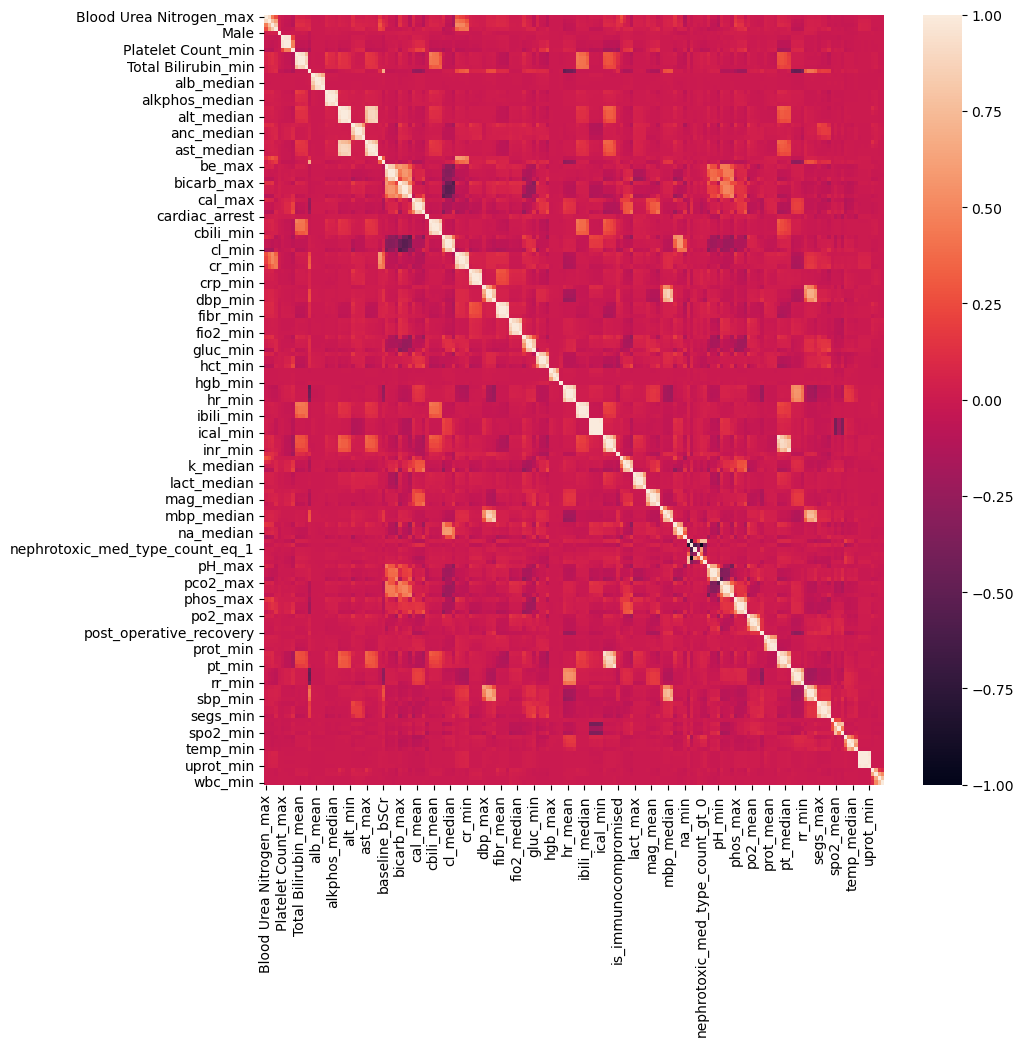

In [29]:
plot_correlation_matrix(feature_corr_pearson_v1)

#### Latest Lab and Median Imputation

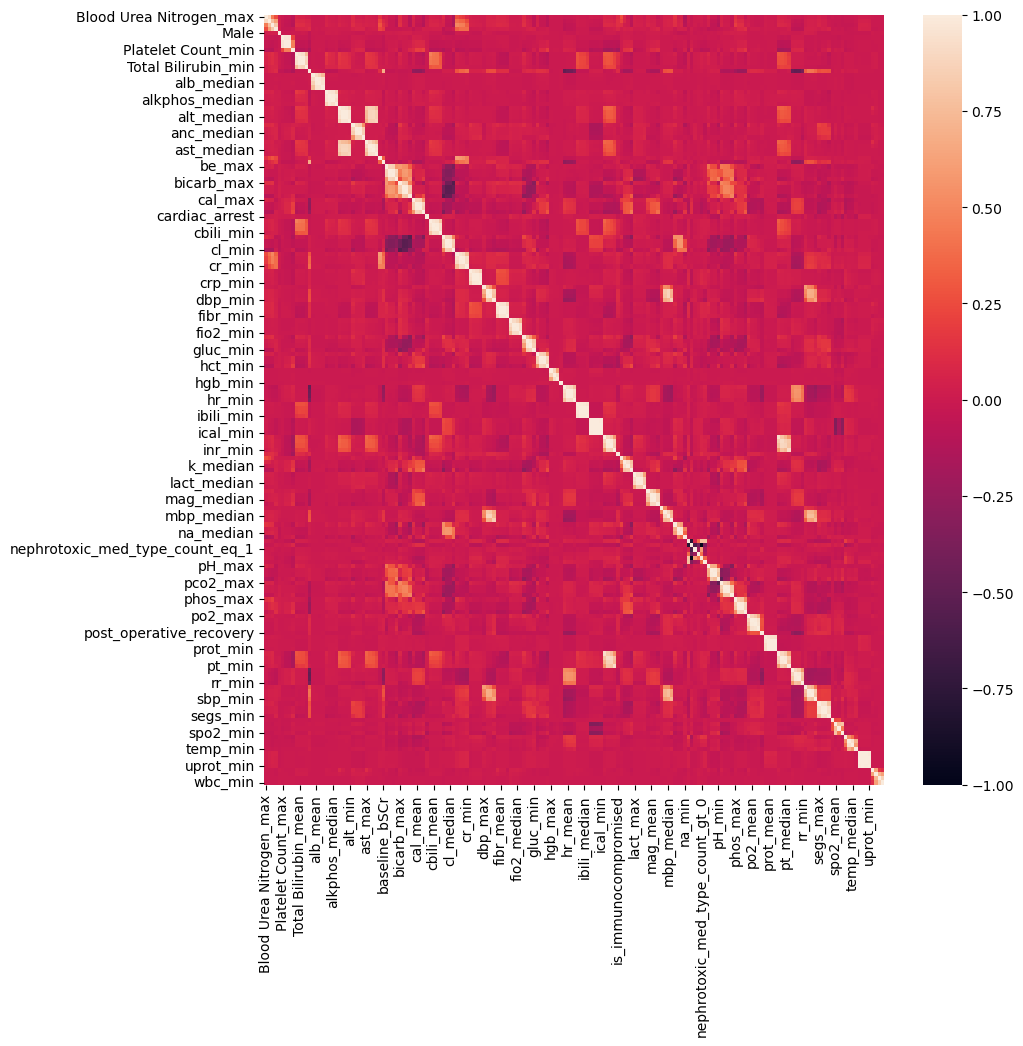

In [30]:
plot_correlation_matrix(feature_corr_pearson_v2)

### Plot Kendall correlation

#### Median imputation

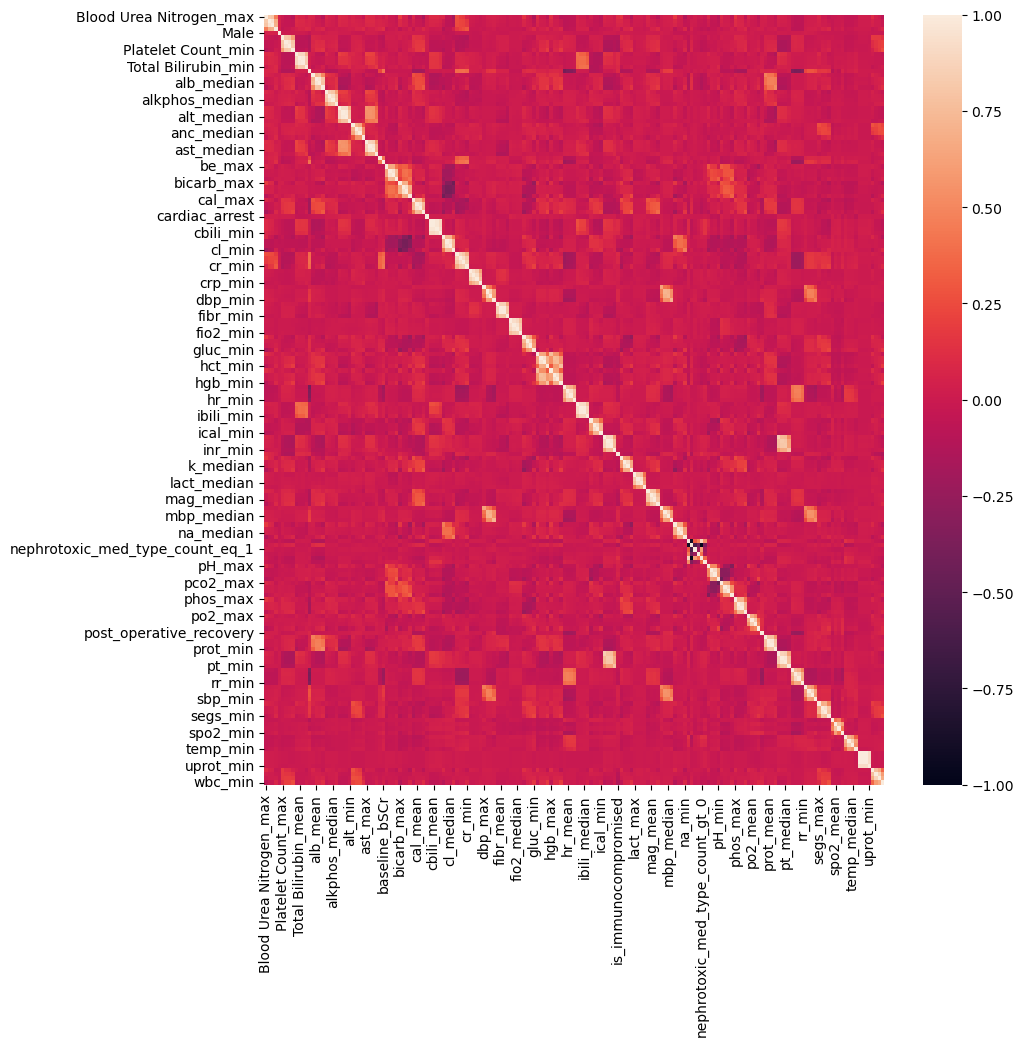

In [31]:
plot_correlation_matrix(feature_corr_kendall_v1)

#### Latest lab and median imputation

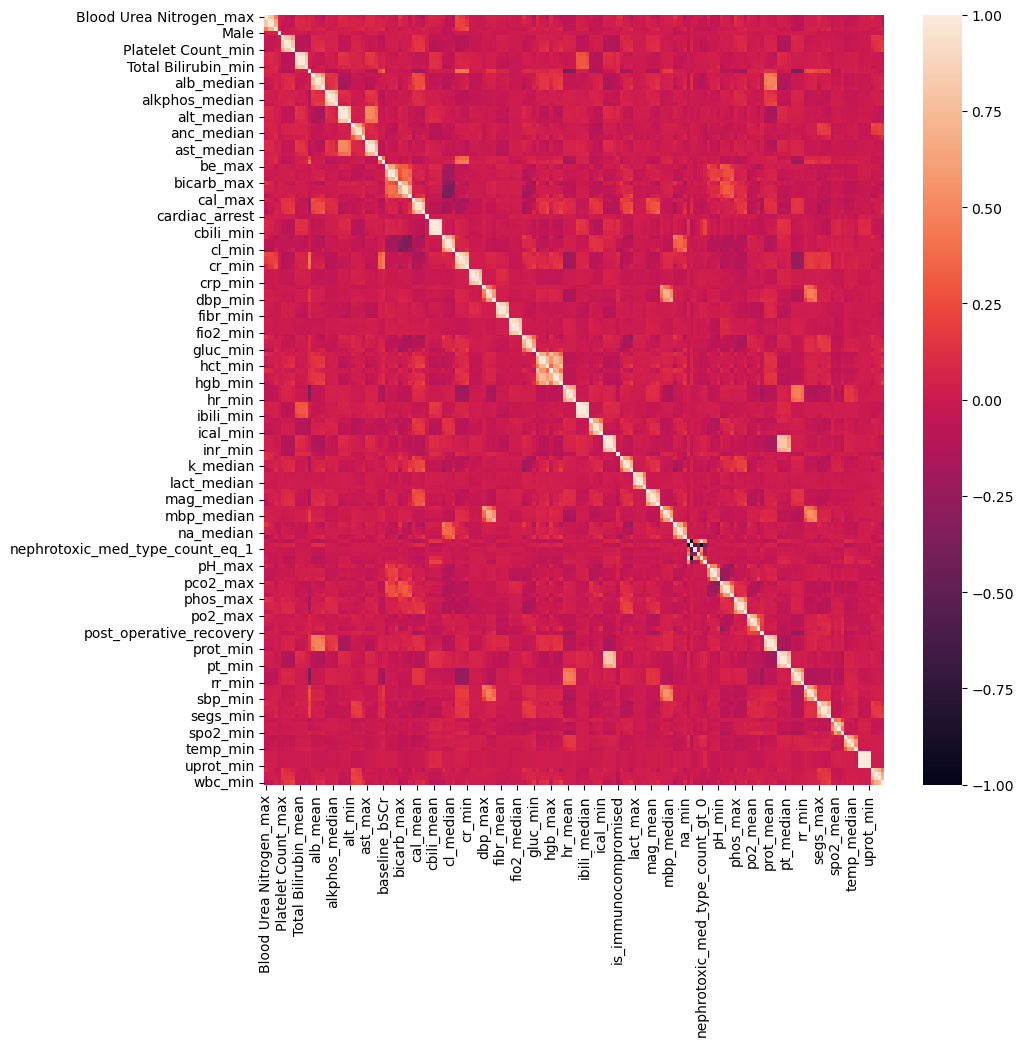

In [32]:
plot_correlation_matrix(feature_corr_kendall_v2)

### Plot Spearman correlation

#### Median imputation

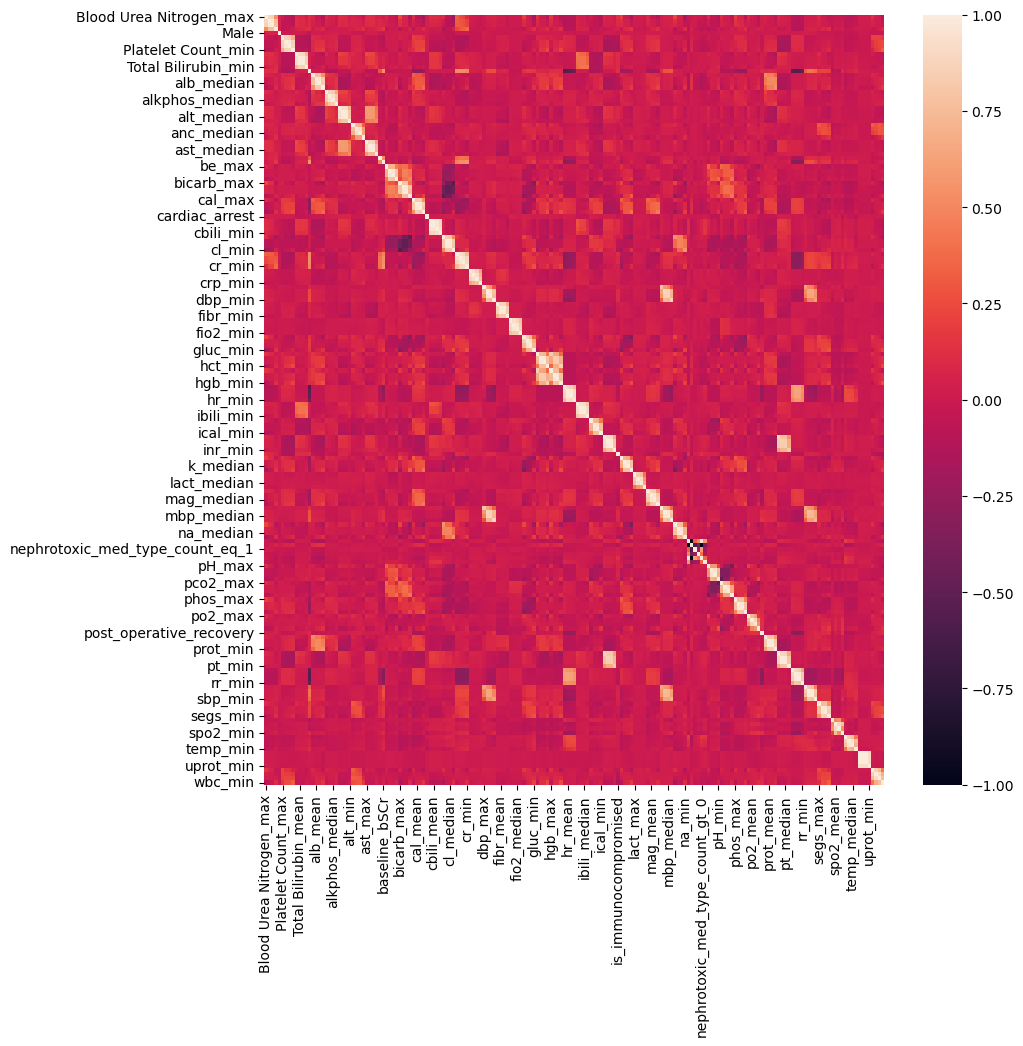

In [33]:
plot_correlation_matrix(feature_corr_spearman_v1)

#### Latest lab and median imputation

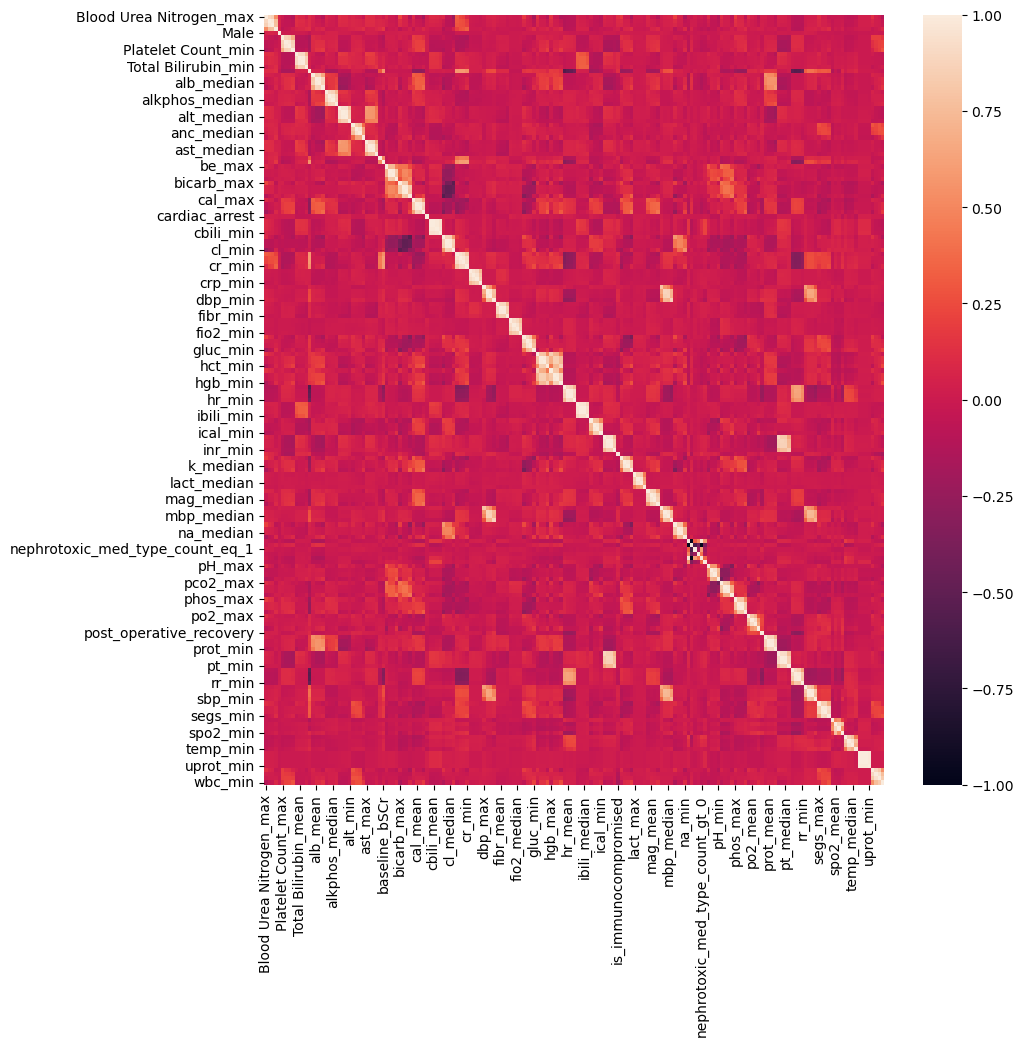

In [34]:
plot_correlation_matrix(feature_corr_spearman_v2)

## Get maximum correlation (across correlation types) for each feature pair and return all feature pairs where this correlation is greater than 0.8

In [40]:
def get_pairwise_correlation_dataframe(corr_mtx, corr_col_name='corr'):
    features_used = []
    pairwise_corr_dict_list = []
    
    for feature1 in corr_mtx.columns:
        for feature2 in corr_mtx.columns:
            if feature2 not in features_used and feature2 != feature1:
                corr_value = corr_mtx[feature1].loc[feature2]
                temp_dict = {
                    'feature1': feature1,
                    'feature2': feature2,
                    corr_col_name: corr_value
                }
                pairwise_corr_dict_list.append(temp_dict)
    
        features_used.append(feature1)
    
    pairwise_corr_df = pd.DataFrame(pairwise_corr_dict_list)

    return pairwise_corr_df

def get_collinear_pairs_df(corr_mtx_dict, corr_thresh=0.8):
    # pairwise_corr_mtx_dict = dict()
    pairwise_corr_df = pd.DataFrame()
    for key in corr_mtx_dict.keys():
        pairwise_corr_mtx = get_pairwise_correlation_dataframe(corr_mtx_dict[key], key)
        pairwise_corr_mtx[key + '_abs'] = [abs(x) for x in pairwise_corr_mtx[key]]
        if len(pairwise_corr_df) == 0:
            pairwise_corr_df = pairwise_corr_mtx.copy()
        else:
            pairwise_corr_df = pairwise_corr_df.merge(
                pairwise_corr_mtx,
                on=['feature1', 'feature2'],
            )
    pairwise_corr_df['max_abs_corr'] = pairwise_corr_df[[key + '_abs' for key in corr_mtx_dict.keys()]].max(axis=1)
    collinear_pairs_df = pairwise_corr_df[pairwise_corr_df['max_abs_corr'] > corr_thresh]

    return collinear_pairs_df

In [42]:
collinear_pairs_df_dict = dict()

corr_mtx_dict_v1 = {
    'pearson': feature_corr_pearson_v1,
    'kendall': feature_corr_kendall_v1,
    'spearman': feature_corr_spearman_v1
}
collinear_pairs_df_dict['v1'] = get_collinear_pairs_df(corr_mtx_dict_v1)

corr_mtx_dict_v2 = {
    'pearson': feature_corr_pearson_v2,
    'kendall': feature_corr_kendall_v2,
    'spearman': feature_corr_spearman_v2
}
collinear_pairs_df_dict['v2'] = get_collinear_pairs_df(corr_mtx_dict_v2)

### Find better feature by each imputation method/model/metric

In [49]:
def get_better_feature_from_pair(feature1, feature2, results_df, imp_key, model_key, metric_key):
    feature1_metric_val = results_df[results_df['input_feature']==feature1].iloc[0][model_key + '_' + metric_key + '_' + imp_key]
    feature2_metric_val = results_df[results_df['input_feature']==feature2].iloc[0][model_key + '_' + metric_key + '_' + imp_key]
    if feature1_metric_val > feature2_metric_val:
        return 1
    else:
        return 2

In [50]:
imp_method_keys = ['v1', 'v2']
model_keys = ['logreg', 'svc']
metric_keys = ['auroc', 'auprc']

better_feature_dict_list = []

for imp_key in imp_method_keys:
    temp_pairs_df = collinear_pairs_df_dict[imp_key]
    for model_key in model_keys:
        for metric_key in metric_keys:
            for i in range(len(temp_pairs_df)):
                feature1 = temp_pairs_df.iloc[i]['feature1']
                feature2 = temp_pairs_df.iloc[i]['feature2']
                temp_dict = {
                    'imp': imp_key,
                    'model': model_key,
                    'metric': metric_key,
                    'feature1': feature1,
                    'feature2': feature2,
                    'better_feature': get_better_feature_from_pair(feature1, feature2, combined_results_df, imp_key, model_key, metric_key)
                }
                better_feature_dict_list.append(temp_dict)

better_feature_df = pd.DataFrame(better_feature_dict_list)

In [52]:
better_feature_df

,imp,model,metric,feature1,feature2,better_feature
0,v1,logreg,auroc,Blood Urea Nitrogen_max,Blood Urea Nitrogen_mean,1
1,v1,logreg,auroc,Blood Urea Nitrogen_max,Blood Urea Nitrogen_median,1
2,v1,logreg,auroc,Blood Urea Nitrogen_mean,Blood Urea Nitrogen_median,1
3,v1,logreg,auroc,Blood Urea Nitrogen_median,Blood Urea Nitrogen_min,1
4,v1,logreg,auroc,Platelet Count_max,Platelet Count_mean,2
...,...,...,...,...,...,...
1763,v2,svc,auprc,uprot_median,uprot_min,2
1764,v2,svc,auprc,wbc_max,wbc_mean,1
1765,v2,svc,auprc,wbc_max,wbc_median,1
1766,v2,svc,auprc,wbc_mean,wbc_median,2


In [56]:
combined_results_df.head().T

,0,1,2,3,4
input_feature,age,bSCr_prior,baseline_bSCr,anc_min,be_min
svc_auroc_v1,0.477406,0.382827,0.503878,0.50084,0.596655
svc_auprc_v1,0.022697,0.017478,0.026608,0.023749,0.031048
svc_auroc_v2,0.477406,0.382827,0.503878,0.50084,0.596655
svc_auprc_v2,0.022697,0.017478,0.026608,0.023749,0.031048
logreg_auroc_v1,0.593807,0.565184,0.563993,0.524428,0.53989
logreg_auprc_v1,0.032831,0.128242,0.06185,0.024148,0.030398
logreg_auroc_v2,0.593807,0.565184,0.563993,0.524428,0.53989
logreg_auprc_v2,0.032831,0.128242,0.06185,0.024148,0.030398
model_type,SVC,SVC,SVC,SVC,SVC


Create a reformatted dataframe of results of single-feature model performance that can be joined with the dataframe of collinear feature pairs.

In [66]:
new_results_df_list = []
for col in combined_results_df.columns:
    if 'v1' in col or 'v2' in col:
        temp_df = combined_results_df[['input_feature', col]].copy()
        temp_df['model'] = [col.split('_')[0] for i in range(len(temp_df))]
        temp_df['metric'] = [col.split('_')[1] for i in range(len(temp_df))]
        temp_df['imp'] = [col.split('_')[2] for i in range(len(temp_df))]
        temp_df['auc'] = temp_df[col].copy()
        temp_df.drop(col, axis=1, inplace=True)
        new_results_df_list.append(temp_df)

new_combined_results_df = pd.concat(new_results_df_list)

new_combined_results_df.head()

,input_feature,model,metric,imp,auc
0,age,svc,auroc,v1,0.477406
1,bSCr_prior,svc,auroc,v1,0.382827
2,baseline_bSCr,svc,auroc,v1,0.503878
3,anc_min,svc,auroc,v1,0.500840
4,be_min,svc,auroc,v1,0.596655


In [71]:
# feature1_merge_df = new_combined_results_df.copy()
new_combined_results_df['auc1'] = new_combined_results_df['auc'].copy()
new_combined_results_df['auc2'] = new_combined_results_df['auc'].copy()

pairs_with_results_df = better_feature_df.merge(
    new_combined_results_df[['input_feature', 'auc1', 'imp', 'model', 'metric']],
    left_on=['feature1', 'imp', 'model', 'metric'],
    right_on=['input_feature', 'imp', 'model', 'metric'],
    how='left'
).drop('input_feature', axis=1).merge(
    new_combined_results_df[['input_feature', 'auc2', 'imp', 'model', 'metric']],
    left_on=['feature2', 'imp', 'model', 'metric'],
    right_on=['input_feature', 'imp', 'model', 'metric'],
    how='left'
).drop('input_feature', axis=1)

pairs_with_results_df['auc_mean'] = 0.5 * (pairs_with_results_df['auc1'] + pairs_with_results_df['auc2'])

In [72]:
pairs_with_results_df

,imp,model,metric,feature1,feature2,better_feature,auc1,auc2,auc_mean
0,v1,logreg,auroc,Blood Urea Nitrogen_max,Blood Urea Nitrogen_mean,1,0.666332,0.662148,0.664240
1,v1,logreg,auroc,Blood Urea Nitrogen_max,Blood Urea Nitrogen_median,1,0.666332,0.652592,0.659462
2,v1,logreg,auroc,Blood Urea Nitrogen_mean,Blood Urea Nitrogen_median,1,0.662148,0.652592,0.657370
3,v1,logreg,auroc,Blood Urea Nitrogen_median,Blood Urea Nitrogen_min,1,0.652592,0.632446,0.642519
4,v1,logreg,auroc,Platelet Count_max,Platelet Count_mean,2,0.552924,0.598640,0.575782
...,...,...,...,...,...,...,...,...,...
1763,v2,svc,auprc,uprot_median,uprot_min,2,0.021827,0.021935,0.021881
1764,v2,svc,auprc,wbc_max,wbc_mean,1,0.030574,0.021400,0.025987
1765,v2,svc,auprc,wbc_max,wbc_median,1,0.030574,0.021512,0.026043
1766,v2,svc,auprc,wbc_mean,wbc_median,2,0.021400,0.021512,0.021456


Go through feature pair list associated with each combination of model type/metric/imputation version and remove the feature with lower performance.

In [86]:
def get_trimmed_feature_list(feature_pair_df, model_type, metric, imputation_version):
    temp_df = feature_pair_df[(feature_pair_df['model']==model_type) & (feature_pair_df['metric']==metric) & (feature_pair_df['imp']==imputation_version)].copy()
    temp_df.sort_values('auc_mean', ascending=False, inplace=True)
    temp_df.reset_index(inplace=True)
    features_to_keep = []
    features_to_remove = []
    for i in range(len(temp_df)):
        feature1 = temp_df.iloc[i]['feature1']
        feature2 = temp_df.iloc[i]['feature2']
        better_feature = temp_df.iloc[i]['feature' + str(temp_df.iloc[i]['better_feature'])]
        if better_feature == feature1:
            worse_feature = feature2
        else:
            worse_feature = feature1
        if better_feature not in features_to_remove and better_feature not in features_to_keep:
            features_to_keep.append(better_feature)
        if worse_feature not in features_to_remove:
            features_to_remove.append(worse_feature)
    return features_to_keep

In [87]:
kept_features_dict = dict()

for model_type in ['logreg', 'svc']:
    for metric in ['auroc', 'auprc']:
        for imp in ['v1', 'v2']:
            # try:
            feature_set_key = model_type + '_' + metric + '_' + imp
            kept_features_dict[feature_set_key] = get_trimmed_feature_list(pairs_with_results_df, model_type, metric, imp)
            # except:
            #     print('imp: ' + imp)
            #     print('metric: ' + metric)
            #     print('model: ' + model_type)

In [89]:
for key in kept_features_dict.keys():
    print(key)
    print(len(kept_features_dict[key]))

logreg_auroc_v1
49
logreg_auroc_v2
51
logreg_auprc_v1
50
logreg_auprc_v2
52
svc_auroc_v1
54
svc_auroc_v2
53
svc_auprc_v1
54
svc_auprc_v2
53


Combine feature sets for logistic regression and SVC so there is only one feature set per combination of metric and imputation method

In [90]:
final_trimmed_features_dict = dict()

# for model_type in ['logreg', 'svc']:
for metric in ['auroc', 'auprc']:
    for imp in ['v1', 'v2']:
        logreg_features = kept_features_dict['logreg_' + metric + '_' + imp]
        svc_features = kept_features_dict['svc_' + metric + '_' + imp]
        final_trimmed_features_dict[metric + '_' + imp] = logreg_features + [feature for feature in svc_features if feature not in logreg_features]

In [91]:
for key in final_trimmed_features_dict.keys():
    print(key)
    print(len(final_trimmed_features_dict[key]))

auroc_v1
83
auroc_v2
83
auprc_v1
84
auprc_v2
83


### Save dict of feature sets

In [92]:
with open('2024-03-12 - Dict of Feature Sets After Trimming Collinear Features.pickle', 'wb') as outfile:
    pickle.dump(final_trimmed_features_dict, outfile)